# EchoFM: Downstream Feature Extraction, Reconstruction, and Periodicity Visualization

EchoFM = ViT-L video MAE + **cardiac-cycle (periodicity) learning**:

$\mathcal{L} = \mathcal{L}_{recon}(\text{norm-pix}) + \lambda_t\,\mathcal{L}_{triplet} + \lambda_c\,\mathcal{L}_{cycle\text{-}KL}$

- **recon**: masked reconstruction (75% spatio-temporally consistent masking, per-patch normalized targets)
- **triplet**: positives/negatives selected by a pixel-space cycle-similarity prior, hard mining, cosine margin 0.2
- **cycle-KL**: per-anchor embedding-similarity distributions distilled toward the (static-component-removed) pixel prior — this is what makes the embeddings phase-aware

In [1]:
import os, sys, glob
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from EchoFM import models_mae
from data.dataset import EchoDataset_from_cache_npy

RUN_DIR = os.path.abspath('../logs/echofm_mae_vitl_f32_v3_0807')
CKPT = sorted(glob.glob(f'{RUN_DIR}/checkpoint-*.pth'))[-1]  # latest checkpoint
DATA = '/mnt/weka/wekafs/mm_fm_training/echo_pretrain_apical2/clips'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = models_mae.mae_vit_large_patch16(
    num_frames=32, t_patch_size=4, pred_t_dim=8,
    sep_pos_embed=True, cls_embed=True, norm_pix_loss=True,
).to(device).eval()
ckpt = torch.load(CKPT, map_location='cpu')
model.load_state_dict(ckpt.get('model', ckpt), strict=False)
print(f'loaded {os.path.basename(CKPT)} (epoch {ckpt.get("epoch", "?")})')

/home/sk1064/workspace/lvfp/extra_pkgs/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/sk1064/workspace/lvfp/extra_pkgs/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


img_size (224, 224) patch_size (16, 16) frames 32 t_patch_size 4


model initialized


/tmp/ipykernel_3110710/3154524067.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT, map_location='cpu')


loaded checkpoint-00050.pth (epoch 50)


## 1. Feature extraction for downstream tasks

Run the encoder without masking (`mask_ratio=0`) to obtain three levels of representation:

| representation | shape | typical use |
|---|---|---|
| token features `latent` | `[B, 8·196, 1024]` | dense prediction (segmentation, ...) |
| per-frame (phase) embeddings `cls_stack` | `[B, 8, 1024]` | phase-aware tasks, EF / LV function regression |
| video embedding `video_emb` | `[B, 1024]` | classification / regression linear probe |

In [2]:
ds = EchoDataset_from_cache_npy(DATA, num_frames=32, image_size=224, frame_stride=1)
imgs = torch.stack([ds[i] for i in (0, 1)]).to(device)  # [B, 3, 32, 224, 224]

@torch.no_grad()
def extract_features(model, imgs):
    latent, _, _ = model.forward_encoder(imgs, mask_ratio=0.0)   # [B, T*L, C]
    cls_stack = torch.stack(model.forward_prj(latent), dim=1)     # [B, T, C] per-frame
    video_emb = latent.mean(dim=1)                                # [B, C] pooled
    return latent, cls_stack, video_emb

latent, cls_stack, video_emb = extract_features(model, imgs)
print('latent   ', tuple(latent.shape))
print('cls_stack', tuple(cls_stack.shape))
print('video_emb', tuple(video_emb.shape))

# downstream linear-probe example (n_out=1 for e.g. EF regression)
probe = nn.Linear(video_emb.shape[-1], 1).to(device)
print('probe out', tuple(probe(video_emb).shape))

41258 cached clips found at /mnt/weka/wekafs/mm_fm_training/echo_pretrain_apical2/clips
41258 cached clips total


latent    (2, 1568, 1024)
cls_stack (2, 8, 1024)
video_emb (2, 1024)
probe out (2, 1)


## 2. Masked reconstruction

Reconstruct with the training mask ratio (75%). Since the model is trained with `norm_pix_loss`, predictions are de-normalized with the per-patch target mean/variance before display.

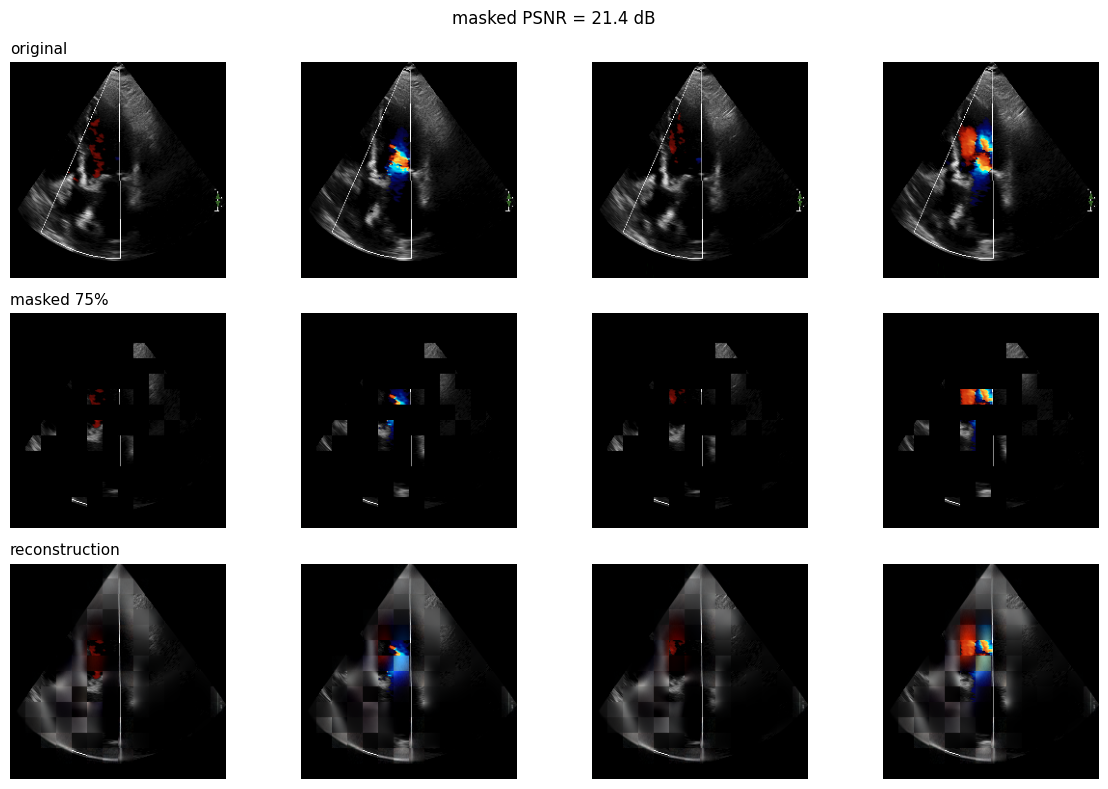

In [3]:
@torch.no_grad()
def reconstruct(model, imgs, mask_ratio=0.75):
    loss, pred, mask, parts = model(imgs, mask_ratio=mask_ratio)
    _imgs = torch.index_select(imgs, 2, torch.linspace(0, imgs.shape[2]-1, model.pred_t_dim).long().to(imgs.device))
    target = model.patchify(_imgs)
    mean, var = target.mean(-1, keepdim=True), target.var(-1, keepdim=True)
    pred_pix = pred * (var + 1e-6).sqrt() + mean
    m = mask.view(imgs.shape[0], -1, 1)
    recon = model.unpatchify(target*(1-m) + pred_pix*m).clamp(0, 1)
    masked = model.unpatchify(target*(1-m))
    orig  = model.unpatchify(target)
    mse = (((pred_pix-target)**2).mean(-1)*mask.view(m.shape[0],-1)).sum()/mask.sum()
    psnr = 10*torch.log10(1.0/(mse+1e-12))
    return orig, masked, recon, float(psnr)

orig, masked, recon, psnr = reconstruct(model, imgs[:1])
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for r, (name, vid) in enumerate([('original', orig), ('masked 75%', masked), ('reconstruction', recon)]):
    for c, f in enumerate([0, 2, 4, 6]):
        axes[r, c].imshow(vid[0, :, f].permute(1, 2, 0).cpu().numpy().clip(0, 1))
        axes[r, c].axis('off')
        if c == 0: axes[r, c].set_title(name, loc='left', fontsize=11)
fig.suptitle(f'masked PSNR = {psnr:.1f} dB', fontsize=12); plt.tight_layout(); plt.show()

## 3. Periodicity visualization

**Success criterion**: the embedding similarity follows the pixel-space cycle similarity (the ground-truth phase structure).
- similarity map: diagonal banding = periodicity
- lag curve: minimum at half a cycle, rebound at one full cycle — the fingerprint of a periodic signal
- ED/ES test: `sim(ED, ED-next-cycle)` must exceed `sim(ED, ES)`

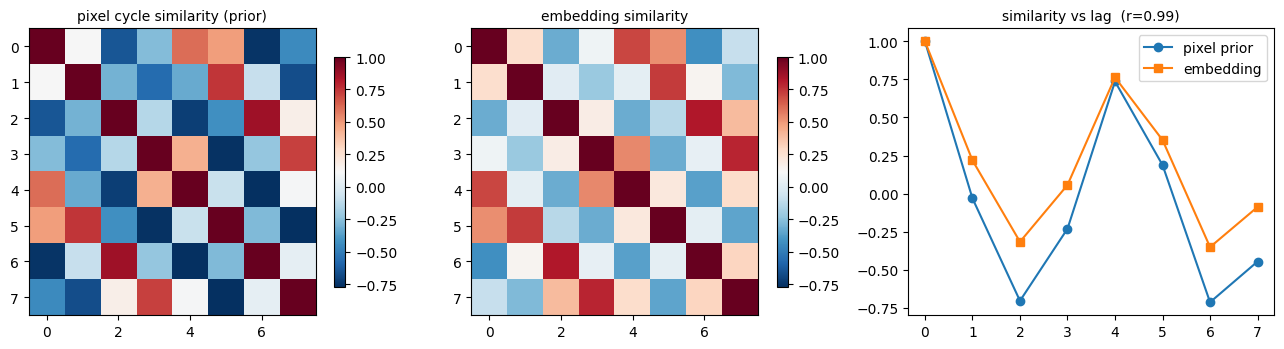

In [4]:
@torch.no_grad()
def similarity_maps(model, imgs):
    latent, _, _ = model.forward_encoder(imgs, mask_ratio=0.0)
    z = F.normalize(torch.stack(model.forward_prj(latent), dim=1), dim=-1)
    embed_sim = torch.bmm(z, z.transpose(1, 2))
    prior_sim = model.pixel_similarity(imgs)   # pixel prior (static component removed)
    return embed_sim[0].cpu().numpy(), prior_sim[0].cpu().numpy()

e, p = similarity_maps(model, imgs[:1])
off = ~np.eye(8, dtype=bool)
r = np.corrcoef(e[off], p[off])[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
vlo = min(e[off].min(), p[off].min())
for ax, m, t in zip(axes[:2], [p, e], ['pixel cycle similarity (prior)', 'embedding similarity']):
    im = ax.imshow(m, vmin=vlo, vmax=1, cmap='RdBu_r'); ax.set_title(t, fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8)
lag = lambda s: [np.mean([s[t_, t_+k] for t_ in range(8-k)]) for k in range(8)]
axes[2].plot(lag(p), 'o-', label='pixel prior'); axes[2].plot(lag(e), 's-', label='embedding')
axes[2].set_title(f'similarity vs lag  (r={r:.2f})', fontsize=10); axes[2].legend()
plt.tight_layout(); plt.show()

In [5]:
# ED/ES test: detect ED (max ventricular cavity) / ES (min) from a cavity-size proxy;
# ED' is implied by the estimated cycle length.
from tools.visualize_ed_es import cavity_curve, cycle_length, find_ed_es

clip = imgs[:1].cpu()
area = cavity_curve(clip); L = cycle_length(clip)
eds, es = find_ed_es(area, L)
print(f'cycle length = {L} frames, ED = {eds}, ES = {es}')
if len(eds) == 2:
    t = lambda f: min(f // 4, 7)
    same, opp = e[t(eds[0]), t(eds[1])], 0.5*(e[t(eds[0]), t(es)] + e[t(eds[1]), t(es)])
    print(f"embedding: sim(ED, ED') = {same:.3f} vs sim(ED, ES) = {opp:.3f} -> "
          f"{'PASS: same phase closer (periodicity learned)' if same > opp else 'FAIL'}")
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
    axes[0].plot(area, color='0.4'); axes[0].plot(eds, area[eds], '^r', ms=12); axes[0].plot([es], [area[es]], 'vb', ms=12)
    axes[0].set_title('LV cavity proxy', fontsize=10)
    for ax, (f, name, c) in zip(axes[1:], [(eds[0], 'ED', 'crimson'), (es, 'ES', 'royalblue'), (eds[1], "ED'", 'crimson')]):
        ax.imshow(clip[0, :, f].permute(1, 2, 0).numpy().clip(0, 1)); ax.set_title(f'{name} (frame {f})', color=c)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

cycle length = 17 frames, ED = [14, 31], ES = 27
embedding: sim(ED, ED') = 0.789 vs sim(ED, ES) = 0.172 -> PASS: same phase closer (periodicity learned)
